## 1. Import Required Libraries

In [4]:
Path.cwd()

PosixPath('/home/mouse/MyData/radar-iwr6843-driver/analysis/notebooks')

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))        # analysis/
sys.path.insert(0, str(Path.cwd().parent / 'lib'))  # analysis/lib/

from rosbag_loader import inspect_bag_topics, load_bag_topics, BagData

sns.set_style('darkgrid')
%matplotlib inline

## 2. Set Bag Path and Inspect Topics

In [7]:
# Use the first available bag
bag_path = 'C:\\Users\\luchs\\MyData\\Education\\Master_TUM\\25WS\\Guided Research\\radar-iwr6843-driver\\rosbags\\backflips_2025-12-17-17-41-24.bag'#rosbags\\circle_forward_2025-12-17-17-37-38.bag' #rosbags\\backflips_2025-12-17-17-41-24.bag'
bag_path = "C:\\Users\\luchs\\MyData\\Education\\Master_TUM\\25WS\\Guided Research\\radar-iwr6843-driver\\rosbags\\circle_2025-12-17-17-21-37.bag"
bag_path = "/home/mouse/MyData/radar-iwr6843-driver/rosbags/Wed_11032026_1503/fastracing_oldconfig_2026-03-11-17-20-18.bag"
# Inspect bag topics
topics_info = inspect_bag_topics(bag_path)


Bag inspection: /home/mouse/MyData/radar-iwr6843-driver/rosbags/Wed_11032026_1503/fastracing_oldconfig_2026-03-11-17-20-18.bag
Duration: 53.60 seconds

Topic                                              Type                                        Count
----------------------------------------------------------------------------------------------------
/angrybird2/active_reference/markers               visualization_msgs/msg/Marker               16112
/angrybird2/active_reference/path                  nav_msgs/msg/Path                           16038
/angrybird2/agiros_pilot/enable                    std_msgs/msg/Bool                               1
/angrybird2/agiros_pilot/go_to_pose                geometry_msgs/msg/PoseStamped                   1
/angrybird2/agiros_pilot/land                      std_msgs/msg/Empty                              2
/angrybird2/agiros_pilot/mpc_command               agiros_msgs/msg/Command                     16072
/angrybird2/agiros_pilot/odometry      

## 3. Load Rosbag Topics into Data Structures

In [8]:
# Load all topics
bag_data = load_bag_topics(bag_path, verbose=True)

# Display summary
print("\nData Summary:")
for key, value in bag_data.summary().items():
    print(f"  {key}: {value}")


Loading rosbag: fastracing_oldconfig_2026-03-11-17-20-18.bag
Duration: 53.60s
  Loading /mocap/angrybird2/pose...
  Loading /mocap/angrybird2/accel...
  Loading /angrybird2/agiros_pilot/state...
  Loading /angrybird2/agiros_pilot/odometry...
  Loading /angrybird2/imu...
  Loading /ti_mmwave/radar_scan_pcl_0...
  Loading /mmWaveDataHdl/RScanVelocity...
  Done!


Data Summary:
  bag_path: /home/mouse/MyData/radar-iwr6843-driver/rosbags/Wed_11032026_1503/fastracing_oldconfig_2026-03-11-17-20-18.bag
  duration_s: 53.599494218826294
  mocap_pose_samples: 13380
  mocap_accel_samples: 13408
  agiros_state_samples: 16107
  agiros_odometry_samples: 16067
  imu_samples: 53150
  radar_pcl_samples: 535
  radar_velocity_samples: 535


## 4. Examine Loaded Data

In [9]:
# MoCap Pose Data
if bag_data.mocap_pose:
    print("\nMoCap Pose (first 3 samples):")
    for pose in bag_data.mocap_pose[:3]:
        print(f"  t={pose.timestamp:.3f}: pos={pose.position}")
else:
    print("No MoCap Pose data found")


MoCap Pose (first 3 samples):
  t=1773246019.181: pos=[ 0.05261355 -0.63309372  0.12620561]
  t=1773246019.183: pos=[ 0.05260772 -0.63304085  0.1261708 ]
  t=1773246019.189: pos=[ 0.05261083 -0.63307051  0.12619129]


In [10]:
# Agiros State Data
if bag_data.agiros_state:
    print("\nAgiros State (first 3 samples):")
    for state in bag_data.agiros_state[:3]:
        print(f"  t={state.timestamp:.3f}: pos={state.position}, vel={state.velocity}")
else:
    print("No Agiros State data found")


Agiros State (first 3 samples):
  t=1773246019.108: pos=[ 0.05262645 -0.63307228  0.12619801], vel=[-0.00019621  0.00091821 -0.00022995]
  t=1773246019.108: pos=[ 0.05264356 -0.63307519  0.12622065], vel=[0.00065786 0.00066041 0.00089641]
  t=1773246019.108: pos=[ 0.05262903 -0.63308525  0.12621543], vel=[-1.59769603e-04  6.50305858e-05  5.07565975e-04]


In [11]:
# IMU Data
if bag_data.imu_data:
    print("\nIMU Data (first 3 samples):")
    for imu in bag_data.imu_data[:3]:
        print(f"  t={imu.timestamp:.3f}: accel={imu.linear_acceleration}, gyro={imu.angular_velocity}")
else:
    print("No IMU data found")


IMU Data (first 3 samples):
  t=1773246019.178: accel=[-1.24587  1.14777  9.78057], gyro=[ 0.016 -0.001 -0.016]
  t=1773246019.179: accel=[-1.25568  1.14777  9.77076], gyro=[ 0.015 -0.002 -0.012]
  t=1773246019.180: accel=[-1.25568  1.13796  9.77076], gyro=[ 0.    -0.004 -0.004]


In [12]:
# Radar Data
if bag_data.radar_pcl:
    print("\nRadar Point Cloud (first 3 samples):")
    for pcl in bag_data.radar_pcl[:3]:
        print(f"  t={pcl.timestamp:.3f}: {pcl.num_points()} points")
else:
    print("No Radar Point Cloud data found")


Radar Point Cloud (first 3 samples):
  t=1773246019.208: 1 points
  t=1773246019.308: 1 points
  t=1773246019.408: 1 points


## 5. Convert to DataFrames for Analysis

In [13]:
# Convert MoCap Pose to DataFrame
if bag_data.mocap_pose:
    mocap_pose_df = pd.DataFrame([pose.to_dict() for pose in bag_data.mocap_pose])
    print("MoCap Pose DataFrame:")
    print(mocap_pose_df.head())
    print(f"Shape: {mocap_pose_df.shape}")

MoCap Pose DataFrame:
      timestamp         x         y         z        qx        qy        qz  \
0  1.773246e+09  0.052614 -0.633094  0.126206  0.006689  0.094111  0.715640   
1  1.773246e+09  0.052608 -0.633041  0.126171  0.006886  0.094010  0.715699   
2  1.773246e+09  0.052611 -0.633071  0.126191  0.006979  0.094047  0.715592   
3  1.773246e+09  0.052649 -0.633069  0.126221  0.006826  0.093916  0.715636   
4  1.773246e+09  0.052610 -0.633080  0.126190  0.006827  0.094097  0.715622   

         qw  
0  0.692068  
1  0.692019  
2  0.692124  
3  0.692097  
4  0.692087  
Shape: (13380, 8)


In [14]:
# Convert Agiros State to DataFrame
if bag_data.agiros_state:
    agiros_state_df = pd.DataFrame([state.to_dict() for state in bag_data.agiros_state])
    print("Agiros State DataFrame:")
    print(agiros_state_df.head())
    print(f"Shape: {agiros_state_df.shape}")

Agiros State DataFrame:
      timestamp         x         y         z        vx        vy        vz  \
0  1.773246e+09  0.052626 -0.633072  0.126198 -0.000196  0.000918 -0.000230   
1  1.773246e+09  0.052644 -0.633075  0.126221  0.000658  0.000660  0.000896   
2  1.773246e+09  0.052629 -0.633085  0.126215 -0.000160  0.000065  0.000508   
3  1.773246e+09  0.052634 -0.633088  0.126223  0.000097 -0.000098  0.000791   
4  1.773246e+09  0.052634 -0.633089  0.126225  0.000099 -0.000101  0.000812   

         qx        qy        qz  ...        wx        wy        wz        ax  \
0  0.007037  0.094009  0.715659  ...  0.009621 -0.016389  0.008313 -0.001573   
1  0.006801  0.093969  0.715670  ... -0.031647  0.016599  0.003432  0.005426   
2  0.006775  0.094076  0.715657  ... -0.007746  0.030196 -0.000153 -0.001423   
3  0.006817  0.094034  0.715627  ... -0.004932  0.008680 -0.008508  0.000699   
4  0.006800  0.094038  0.715618  ... -0.004931  0.008681 -0.008508  0.000699   

         ay        a

In [15]:
# Convert IMU to DataFrame
if bag_data.imu_data:
    imu_df = pd.DataFrame([imu.to_dict() for imu in bag_data.imu_data])
    print("IMU DataFrame:")
    print(imu_df.head())
    print(f"Shape: {imu_df.shape}")

IMU DataFrame:
      timestamp       ax       ay       az     wx     wy     wz
0  1.773246e+09 -1.24587  1.14777  9.78057  0.016 -0.001 -0.016
1  1.773246e+09 -1.25568  1.14777  9.77076  0.015 -0.002 -0.012
2  1.773246e+09 -1.25568  1.13796  9.77076  0.000 -0.004 -0.004
3  1.773246e+09 -1.25568  1.13796  9.77076 -0.005 -0.007 -0.006
4  1.773246e+09 -1.26549  1.13796  9.76095  0.000  0.004  0.003
Shape: (53150, 7)


## 6. Visualization: Trajectory Comparison

In [16]:
len(agiros_state_df['x'])

16107

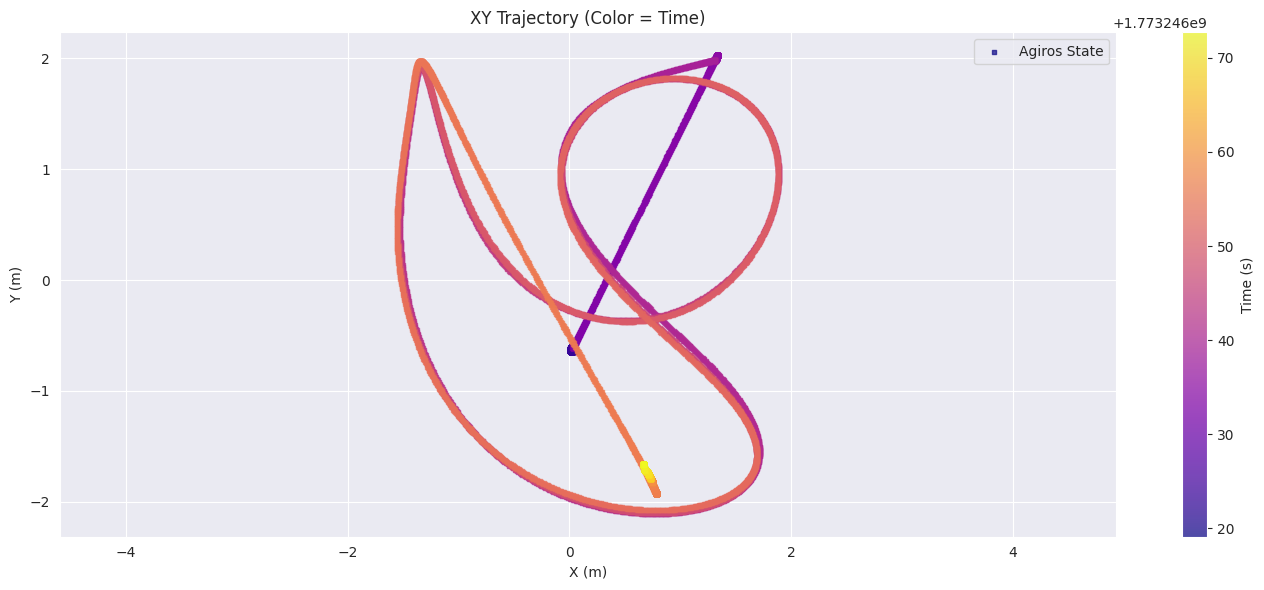

In [17]:
# Plot trajectories from different sensors with color gradient over time
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# # XY trajectory with color gradient
# if bag_data.mocap_pose and mocap_pose_df is not None:
#     points = ax.scatter(mocap_pose_df['x'], mocap_pose_df['y'], 
#                        c=mocap_pose_df['timestamp'], cmap='viridis', 
#                        s=10, alpha=0.7, label='MoCap Pose')
#     plt.colorbar(points, ax=ax, label='Time (s)')

if bag_data.agiros_state and agiros_state_df is not None:
    points2 = ax.scatter(agiros_state_df['x'], agiros_state_df['y'], 
                        c=agiros_state_df['timestamp'], cmap='plasma', 
                        s=10, alpha=0.7, marker='s', label='Agiros State')
    plt.colorbar(points2, ax=ax, label='Time (s)')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('XY Trajectory (Color = Time)')
ax.legend()
ax.grid(True)
ax.axis('equal')

plt.tight_layout()
plt.show()


In [18]:
imu_df

,timestamp,ax,ay,az,wx,wy,wz
0,1.773246e+09,-1.24587,1.14777,9.78057,0.016,-0.001,-0.016
1,1.773246e+09,-1.25568,1.14777,9.77076,0.015,-0.002,-0.012
2,1.773246e+09,-1.25568,1.13796,9.77076,0.000,-0.004,-0.004
3,1.773246e+09,-1.25568,1.13796,9.77076,-0.005,-0.007,-0.006
4,1.773246e+09,-1.26549,1.13796,9.76095,0.000,0.004,0.003
...,...,...,...,...,...,...,...
53145,1.773246e+09,-2.58003,0.00000,9.24102,0.020,0.029,-0.012
53146,1.773246e+09,-2.58003,0.00000,9.24102,0.021,0.027,-0.010
53147,1.773246e+09,-2.58984,0.00000,9.24102,0.021,0.023,-0.006
53148,1.773246e+09,-2.58984,0.00000,9.24102,0.022,0.021,-0.005


## 7. Visualization: IMU Acceleration

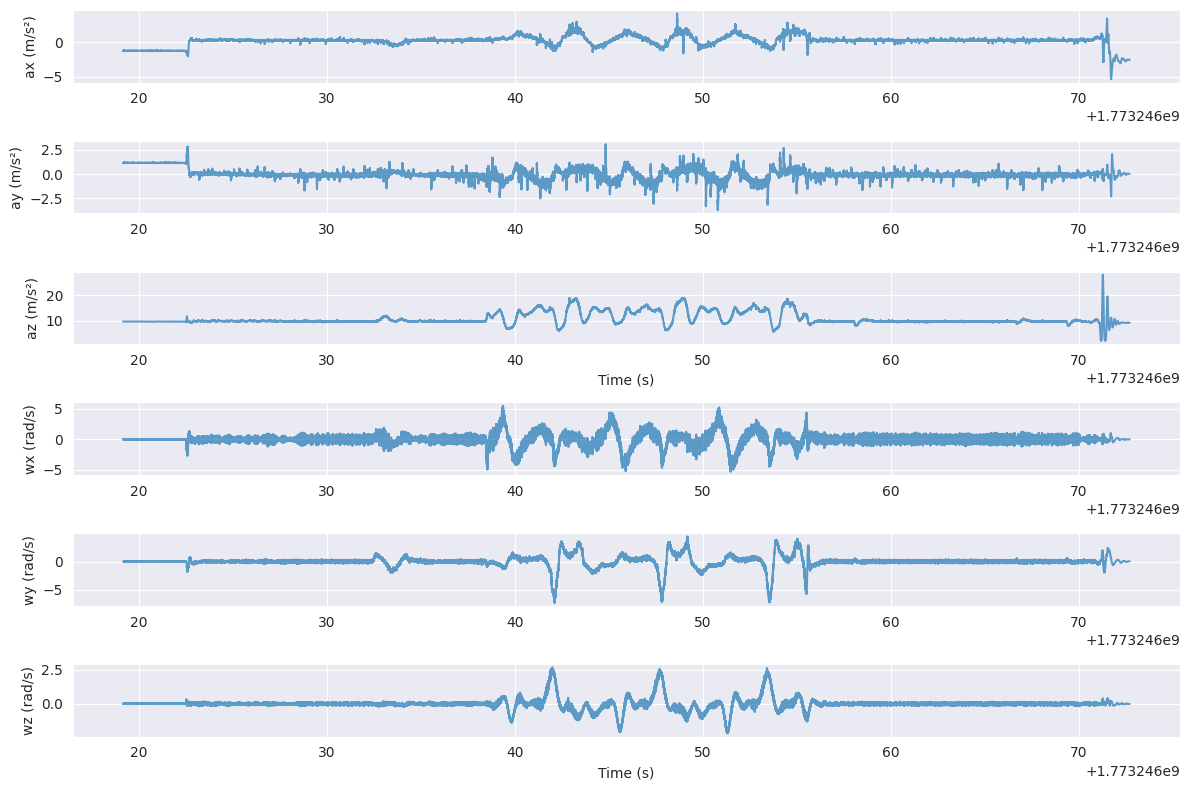

In [19]:
# Plot IMU acceleration
if bag_data.imu_data and imu_df is not None:
    fig, axes = plt.subplots(6, 1, figsize=(12, 8))
    
    axes[0].plot(imu_df['timestamp'], imu_df['ax'], alpha=0.7)
    axes[0].set_ylabel('ax (m/s²)')
    axes[0].grid(True)
    
    axes[1].plot(imu_df['timestamp'], imu_df['ay'], alpha=0.7)
    axes[1].set_ylabel('ay (m/s²)')
    axes[1].grid(True)
    
    axes[2].plot(imu_df['timestamp'], imu_df['az'], alpha=0.7)
    axes[2].set_ylabel('az (m/s²)')
    axes[2].set_xlabel('Time (s)')
    axes[2].grid(True)
    
    axes[3].plot(imu_df['timestamp'], imu_df['wx'], alpha=0.7)
    axes[3].set_ylabel('wx (rad/s)')
    axes[3].grid(True)
    
    axes[4].plot(imu_df['timestamp'], imu_df['wy'], alpha=0.7)
    axes[4].set_ylabel('wy (rad/s)')
    axes[4].grid(True)
    
    axes[5].plot(imu_df['timestamp'], imu_df['wz'], alpha=0.7)
    axes[5].set_ylabel('wz (rad/s)')
    axes[5].set_xlabel('Time (s)')
    axes[5].grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("No IMU data to plot")

## 8. Synchronization Analysis

Find time bounds where all available sensors have data for synchronized processing.

In [20]:
# Get synchronized time bounds
t_min, t_max = bag_data.get_sync_time_bounds()

print(f"\nSynchronization Analysis:")
print(f"  Sync time range: {t_min:.3f} to {t_max:.3f}")
print(f"  Sync duration: {t_max - t_min:.3f} seconds")
print(f"\n  Individual sensor time ranges:")

if bag_data.mocap_pose:
    dt = bag_data.mocap_pose[-1].timestamp - bag_data.mocap_pose[0].timestamp
    print(f"    MoCap Pose: {bag_data.mocap_pose[0].timestamp:.3f} - {bag_data.mocap_pose[-1].timestamp:.3f} ({dt:.3f}s)")

if bag_data.agiros_state:
    dt = bag_data.agiros_state[-1].timestamp - bag_data.agiros_state[0].timestamp
    print(f"    Agiros State: {bag_data.agiros_state[0].timestamp:.3f} - {bag_data.agiros_state[-1].timestamp:.3f} ({dt:.3f}s)")

if bag_data.imu_data:
    dt = bag_data.imu_data[-1].timestamp - bag_data.imu_data[0].timestamp
    print(f"    IMU: {bag_data.imu_data[0].timestamp:.3f} - {bag_data.imu_data[-1].timestamp:.3f} ({dt:.3f}s)")

if bag_data.radar_pcl:
    dt = bag_data.radar_pcl[-1].timestamp - bag_data.radar_pcl[0].timestamp
    print(f"    Radar PCL: {bag_data.radar_pcl[0].timestamp:.3f} - {bag_data.radar_pcl[-1].timestamp:.3f} ({dt:.3f}s)")


Synchronization Analysis:
  Sync time range: 1773246019.208 to 1773246072.703
  Sync duration: 53.496 seconds

  Individual sensor time ranges:
    MoCap Pose: 1773246019.181 - 1773246072.703 (53.522s)
    Agiros State: 1773246019.108 - 1773246072.705 (53.596s)
    IMU: 1773246019.178 - 1773246072.707 (53.529s)
    Radar PCL: 1773246019.208 - 1773246072.707 (53.500s)


## 9. Usage for Factor Graph Pipeline

Example of how to access data for factor graph construction:

In [21]:
# Example: Iterate through synchronized data for factor graph
print("\nExample: Iterating through synchronized data for factor graph construction")
print("="*60)

t_min, t_max = bag_data.get_sync_time_bounds()

# Create index mapping for synchronized data
sync_mocap_idx = [i for i, pose in enumerate(bag_data.mocap_pose) 
                  if t_min <= pose.timestamp <= t_max]
sync_imu_idx = [i for i, imu in enumerate(bag_data.imu_data) 
                if t_min <= imu.timestamp <= t_max]

print(f"\nSynchronized data indices:")
print(f"  MoCap Pose: {len(sync_mocap_idx)} samples")
print(f"  IMU: {len(sync_imu_idx)} samples")

# Example: Get first synchronized pose and IMU measurement
if sync_mocap_idx and sync_imu_idx:
    pose = bag_data.mocap_pose[sync_mocap_idx[0]]
    imu = bag_data.imu_data[sync_imu_idx[0]]
    
    print(f"\nFirst synchronized measurements:")
    print(f"  MoCap Pose: pos={pose.position}, ori={pose.orientation}")
    print(f"  IMU: accel={imu.linear_acceleration}, gyro={imu.angular_velocity}")
    print(f"  Time diff: {abs(pose.timestamp - imu.timestamp):.6f} seconds")


Example: Iterating through synchronized data for factor graph construction

Synchronized data indices:
  MoCap Pose: 13373 samples
  IMU: 53116 samples

First synchronized measurements:
  MoCap Pose: pos=[ 0.0526148  -0.63307561  0.12619575], ori=[0.00693591 0.09408057 0.71560103 0.69210975]
  IMU: accel=[-1.18701  1.14777  9.73152], gyro=[ 0.    -0.016  0.017]
  Time diff: 0.001200 seconds
